# Reservation cancellations: data audit and exploratory patterns

**Purpose.** This notebook covers problem selection, data checks, and descriptive patterns for the CIS 8005 group project. It uses only Kaggle's labeled `train.csv`. A row is one synthetic reservation; `booking_status = 1` means canceled. The proposed operational decision is how to prioritize reservation follow-up and inventory planning before arrival, subject to model validation and business costs.

**Interpretation.** The competition data were generated by a model trained on a prior reservation dataset. All percentages here describe this synthetic file. They do not establish causal effects or a hotel's real-world cancellation rate. Coded category values are left as codes because Kaggle does not supply a verified mapping to business labels in this file.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "train.csv").exists():
    ROOT = ROOT.parent
PROCESSED = ROOT / "data" / "processed" / "train_clean.csv"
if not PROCESSED.exists():
    raise FileNotFoundError("Run notebooks/00_data_preparation.ipynb first")
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(PROCESSED)
print(f"Rows: {len(df):,}; original columns: 19; cancellation rate: {df.booking_status.mean():.1%}")
assert len(df) == 42100 and df.booking_status.isin([0, 1]).all()

Rows: 42,100; original columns: 19; cancellation rate: 39.2%


## 1. Source, target, and decision

The source is [Kaggle Playground Series S3E7](https://www.kaggle.com/competitions/playground-series-s3e7/data). `train.csv` has outcomes; `test.csv` and `sample_submission.csv` are competition artifacts, not evidence for observed cancellation rates. `id` is a row identifier, not a reservation behavior. The question is which reservations in this dataset were more likely to cancel, so a hotel could evaluate a proportionate pre-arrival action such as targeted confirmation or staffing/inventory review. A deployment recommendation needs a validated model, calibrated probabilities, and actual operating costs.

## 2. Audit before transformation

First inspect the raw schema, missingness, duplicates, target balance, and numeric ranges. The preceding preparation notebook keeps every row and every original value, adding only deterministic totals and anomaly flags.

In [2]:
raw = pd.read_csv(ROOT / "data" / "raw" / "train.csv")
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique": raw.nunique(dropna=False),
    "min": raw.min(numeric_only=True),
    "max": raw.max(numeric_only=True),
})
display(audit)
print("Exact duplicate rows:", raw.duplicated().sum())
print("Duplicate rows excluding ID:", raw.drop(columns="id").duplicated().sum())
print("Duplicate IDs:", raw.id.duplicated().sum())
display(raw.booking_status.value_counts().rename(index={0:"Not canceled",1:"Canceled"}).to_frame("reservations"))
display(pd.DataFrame({
    "check": ["invalid calendar date", "zero guests", "zero nights", "zero room price"],
    "rows": [int(df.invalid_arrival_date.sum()), int(df.zero_guests.sum()),
             int(df.zero_nights.sum()), int(df.zero_room_price.sum())],
}))

,dtype,missing,unique,min,max
id,int64,0,42100,0.0,42099.0
no_of_adults,int64,0,5,0.0,4.0
no_of_children,int64,0,6,0.0,9.0
no_of_weekend_nights,int64,0,8,0.0,7.0
no_of_week_nights,int64,0,18,0.0,17.0
type_of_meal_plan,int64,0,4,0.0,3.0
required_car_parking_space,int64,0,2,0.0,1.0
room_type_reserved,int64,0,7,0.0,6.0
lead_time,int64,0,338,0.0,443.0
arrival_year,int64,0,2,2017.0,2018.0


Exact duplicate rows: 0
Duplicate rows excluding ID: 0
Duplicate IDs: 0


,reservations
booking_status,
Not canceled,25596
Canceled,16504


,check,rows
0,invalid calendar date,50
1,zero guests,16
2,zero nights,114
3,zero room price,641


**Cleaning decision.** There are no missing cells or duplicate rows. Some date combinations are impossible, and a few rows have zero guests, nights, or room price. Their meaning is not documented, so we retain them and add flags instead of silently deleting or replacing values. `total_guests` and `total_nights` are sums of existing columns. The original calendar fields stay available; `invalid_arrival_date` identifies dates that cannot be parsed. No target-based transformation is used. `id` is excluded from modeling. Meal plan, room type, and market segment are nominal code fields and should be encoded as categories rather than treated as ordered measurements.

In [3]:
def rates(frame, group):
    return (frame.groupby(group, observed=True).booking_status
            .agg(reservations="size", canceled="sum", cancellation_rate="mean"))

def rate_count_chart(table, title, file_name, xlabel):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    names = table.index.astype(str)
    axes[0].bar(names, table.cancellation_rate * 100, color="#1f5a83")
    axes[0].set_ylabel("Cancellation rate (%)")
    axes[0].set_xlabel(xlabel)
    axes[0].tick_params(axis="x", rotation=35)
    axes[1].bar(names, table.reservations, color="#6c8f72")
    axes[1].set_ylabel("Reservations (n)")
    axes[1].set_xlabel(xlabel)
    axes[1].tick_params(axis="x", rotation=35)
    fig.suptitle(title)
    fig.savefig(FIGURES / file_name, dpi=160)
    plt.show()


## 3. Lead time

Lead time is days between booking and planned arrival. The fixed bands are chosen for readable operational horizons, not optimized against the target. The final band is small, so its rate is less stable. Rates and counts are shown together.

,reservations,canceled,cancellation_rate
lead_band,,,
0–7,4435,486,11.0%
8–30,4598,1023,22.2%
31–90,11576,2946,25.4%
91–180,14298,7141,49.9%
181–365,7002,4761,68.0%
366+,191,147,77.0%


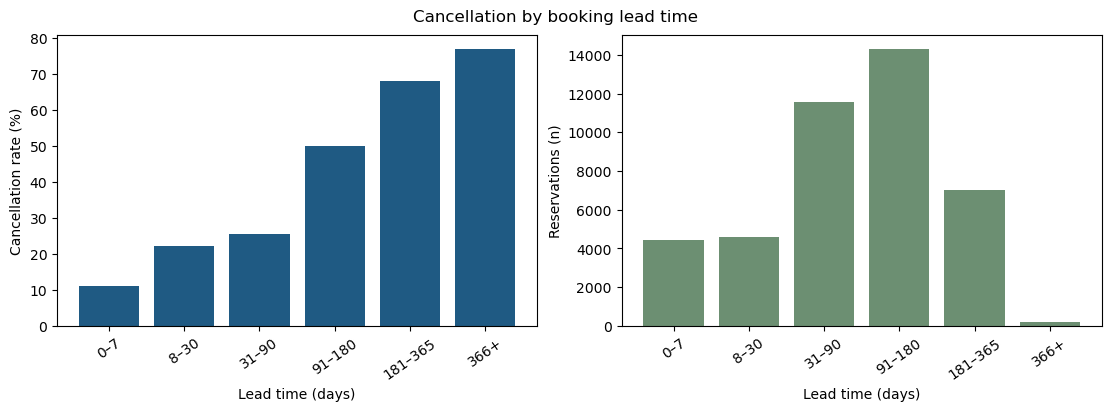

In [4]:
lead_labels = ["0–7", "8–30", "31–90", "91–180", "181–365", "366+"]
df["lead_band"] = pd.cut(df.lead_time, [-1, 7, 30, 90, 180, 365, float("inf")], labels=lead_labels)
lead = rates(df, "lead_band")
display(lead.style.format({"cancellation_rate":"{:.1%}"}))
rate_count_chart(lead, "Cancellation by booking lead time", "lead_time.png", "Lead time (days)")

## 4. Market segment and special requests

Market segment codes describe groups in the file, but their business names are not verified. The request count is already numeric; very high counts have small samples. Both comparisons are descriptive and may reflect differences in other variables.

,reservations,canceled,cancellation_rate
market_segment_type,,,
0,14306,3233,22.6%
1,25885,13084,50.5%
2,1384,162,11.7%
3,83,18,21.7%
4,442,7,1.6%


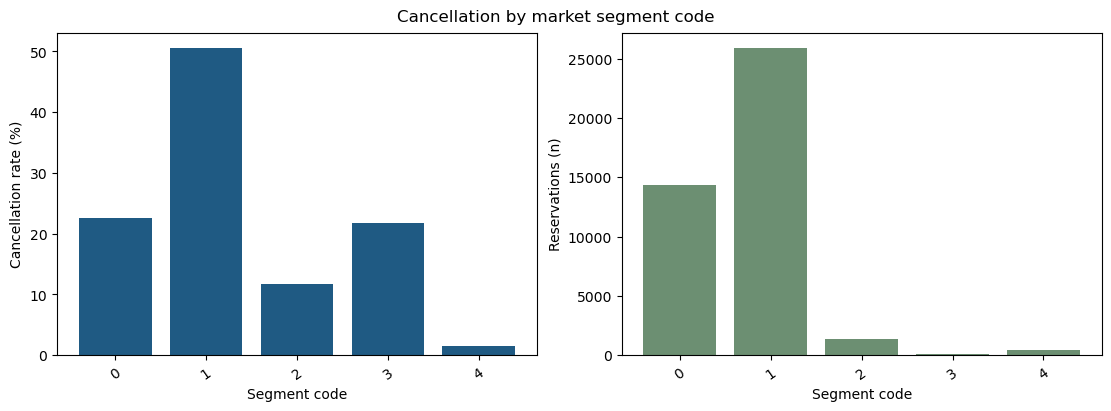

,reservations,canceled,cancellation_rate
no_of_special_requests,,,
0,24554,11710,47.7%
1,11885,3666,30.8%
2,4900,1123,22.9%
3,660,5,0.8%
4,100,0,0.0%
5,1,0,0.0%


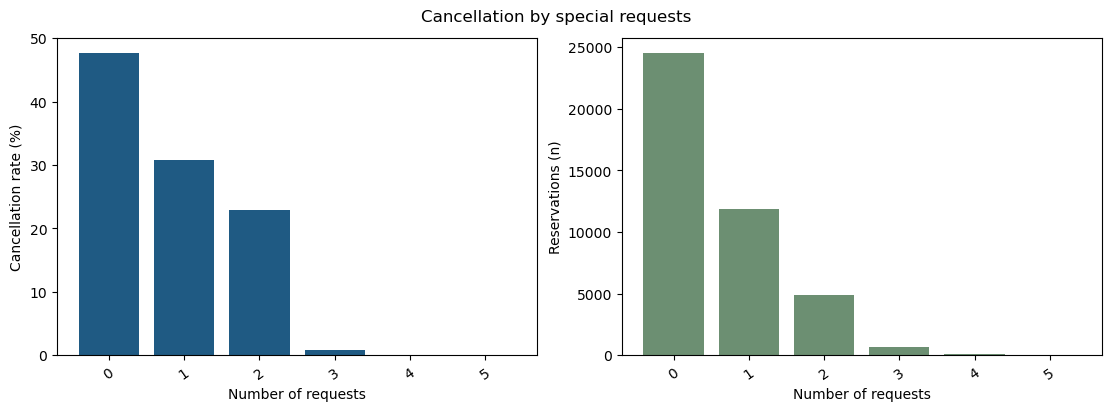

In [5]:
segment = rates(df, "market_segment_type")
requests = rates(df, "no_of_special_requests")
display(segment.style.format({"cancellation_rate":"{:.1%}"}))
rate_count_chart(segment, "Cancellation by market segment code", "market_segment.png", "Segment code")
display(requests.style.format({"cancellation_rate":"{:.1%}"}))
rate_count_chart(requests, "Cancellation by special requests", "special_requests.png", "Number of requests")

## 5. Room price and context checks

Price bands separate zero prices, which may have a special meaning. They are fixed, descriptive bands. We also compare lead-time bands within each arrival year; year and season may confound pooled comparisons. The chart is not a causal estimate of lead time or price.

,reservations,canceled,cancellation_rate
price_band,,,
0,641,27,4.2%
"(0,60]",1549,217,14.0%
"(60,90]",13841,3863,27.9%
"(90,120]",14819,7204,48.6%
"(120,150]",6628,3361,50.7%
"(150,200]",3915,1503,38.4%
>200,707,329,46.5%


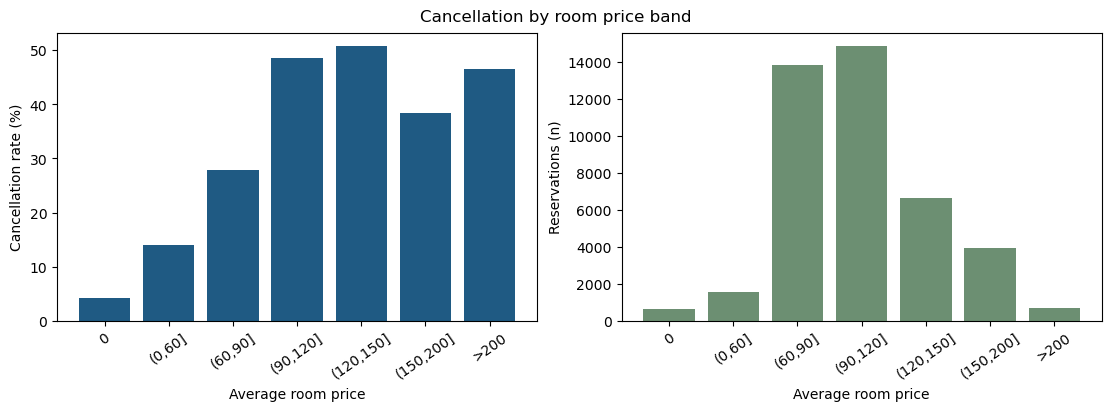

In [6]:
price_labels = ["0", "(0,60]", "(60,90]", "(90,120]", "(120,150]", "(150,200]", ">200"]
df["price_band"] = pd.cut(df.avg_price_per_room, [-0.01, 0, 60, 90, 120, 150, 200, float("inf")], labels=price_labels)
price = rates(df, "price_band")
display(price.style.format({"cancellation_rate":"{:.1%}"}))
rate_count_chart(price, "Cancellation by room price band", "room_price.png", "Average room price")
year_lead = rates(df, ["arrival_year", "lead_band"])
display(year_lead.style.format({"cancellation_rate":"{:.1%}"}))

## 6. Interpretation and modeling handoff

In this synthetic training file, cancellation frequency rises markedly with longer lead time. Segment code 1 and zero special requests also have higher observed rates, while the price pattern is not monotonic. These are associations. Group sizes, cross-tabs, and later validation matter before turning any one pattern into an operational rule. The year difference warrants a validation split that reflects the intended prediction setting.

For modeling, run `00_data_preparation.ipynb`, then read `data/processed/train_clean.csv` in `02_modeling_and_evaluation.ipynb`. Set `y = train["booking_status"]` and `X = train.drop(columns=["id", "booking_status"])`. Use a stratified train/validation split for an initial comparison, and consider a year-based robustness check if operational timing supports it. Keep all learned preprocessing inside the training pipeline. Treat `type_of_meal_plan`, `room_type_reserved`, and `market_segment_type` as categorical codes. `booking_status = 1` is the positive cancellation class. Do not use the unlabeled competition test file for metrics, tuning, or findings. See `reports/analysis_handoff.md` for exact counts, caveats, and open decisions.